# Лабораторная работа: Анализ цен на жильё в Бостоне

Цель: освоить методы предобработки, визуализации, построения и оценки линейной регрессии.

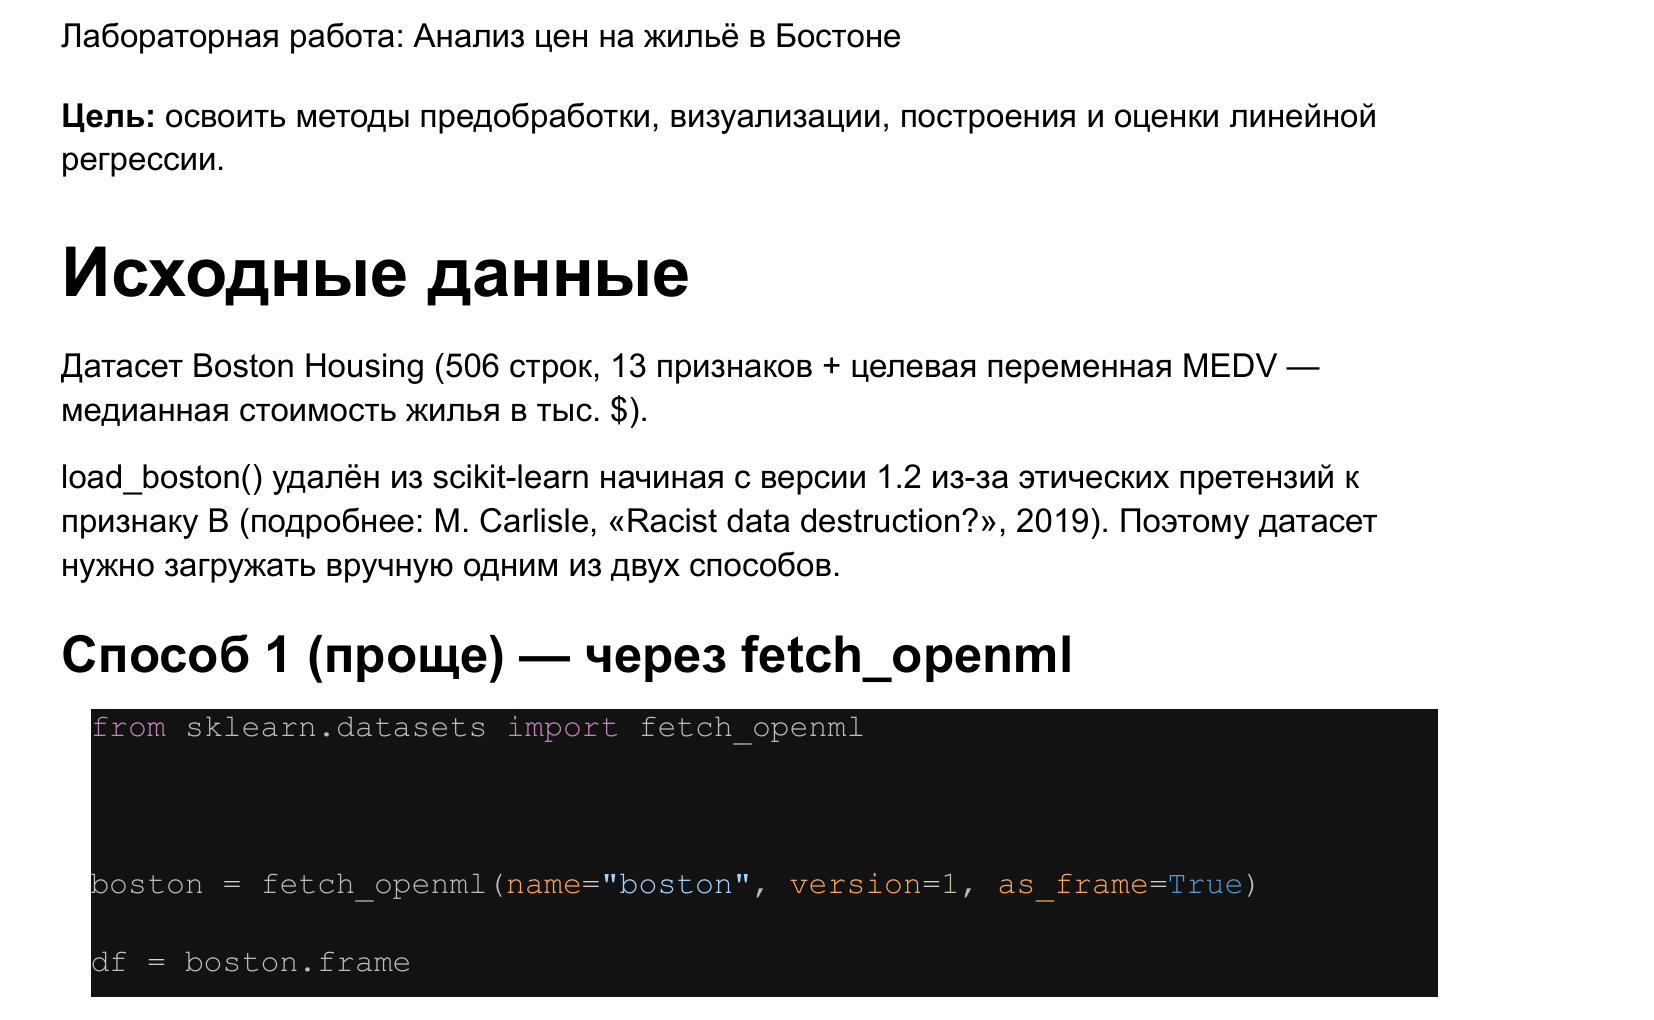

In [3]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml

# способ 1 -- через fetch_openml, самый простой вариант
boston = fetch_openml(name="boston", version=1, as_frame=True)
df = boston.frame

print(df.shape)  # строк, столбцов
df.head()

(506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


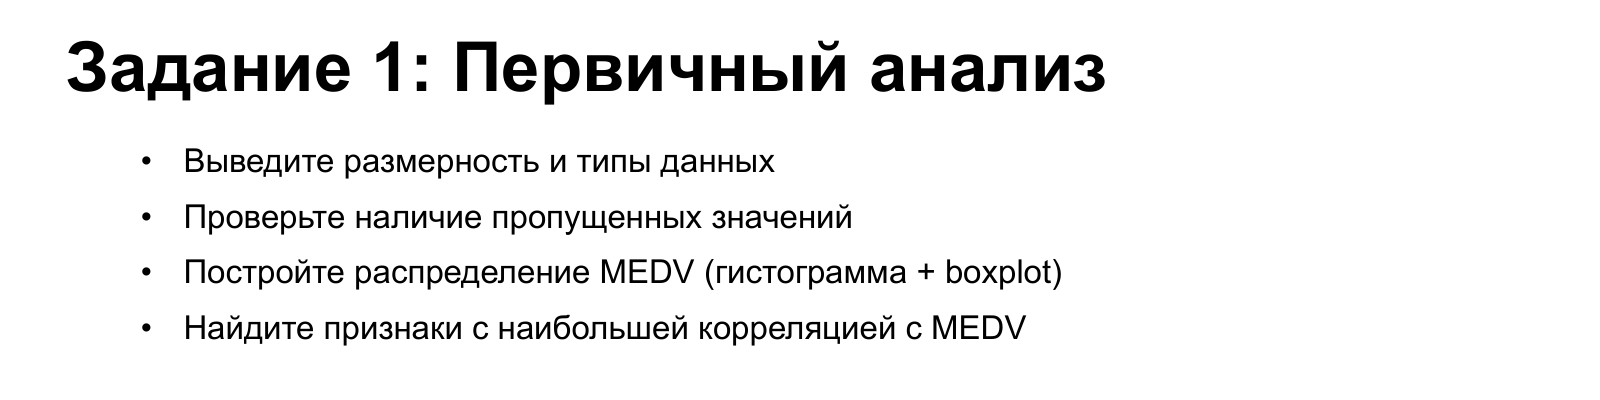

In [4]:
import matplotlib.pyplot as plt

# выведите размерность и типы данных
print(df.shape)  # строк, признаков
df.dtypes  # CHAS и RAD почему-то category, остальное float

(506, 14)


CRIM        float64
ZN          float64
INDUS       float64
CHAS       category
NOX         float64
RM          float64
AGE         float64
DIS         float64
RAD        category
TAX         float64
PTRATIO     float64
B           float64
LSTAT       float64
MEDV        float64
dtype: object

**расшифровка признаков:**

- CRIM — per capita crime rate by town — уровень преступности на душу населения по городам
- ZN — proportion of residential land zoned for lots over 25,000 sq.ft — доля жилой земли под участки больше 25 000 кв.футов
- INDUS — proportion of non-retail business acres per town — доля неторговых бизнес-территорий по городам
- CHAS — Charles River dummy variable (1 if tract bounds river, else 0) — участок граничит с рекой Чарльз (1 -- да, 0 -- нет)
- NOX — nitric oxides concentration (parts per 10 million) — концентрация оксидов азота
- RM — average number of rooms per dwelling — среднее число комнат в доме
- AGE — proportion of owner-occupied units built prior to 1940 — доля домов старше 1940 года
- DIS — weighted distances to five Boston employment centres — взвешенное расстояние до 5 деловых центров Бостона
- RAD — index of accessibility to radial highways — индекс доступности радиальных магистралей
- TAX — full-value property-tax rate per $10,000 — ставка налога на имущество
- PTRATIO — pupil-teacher ratio by town — соотношение учеников и учителей по городам
- B — 1000(Bk − 0.63)², где Bk -- доля чернокожего населения по городам — спорный с этической точки зрения признак (из-за него load_boston() и убрали из sklearn)
- LSTAT — % lower status of the population — процент населения с низким социальным статусом
- MEDV — median value of owner-occupied homes in $1000's — медианная стоимость жилья, тыс. $ (целевая переменная)

In [5]:
# проверьте наличие пропущенных значений
df.isnull().sum()  # пропусков нигде нет

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

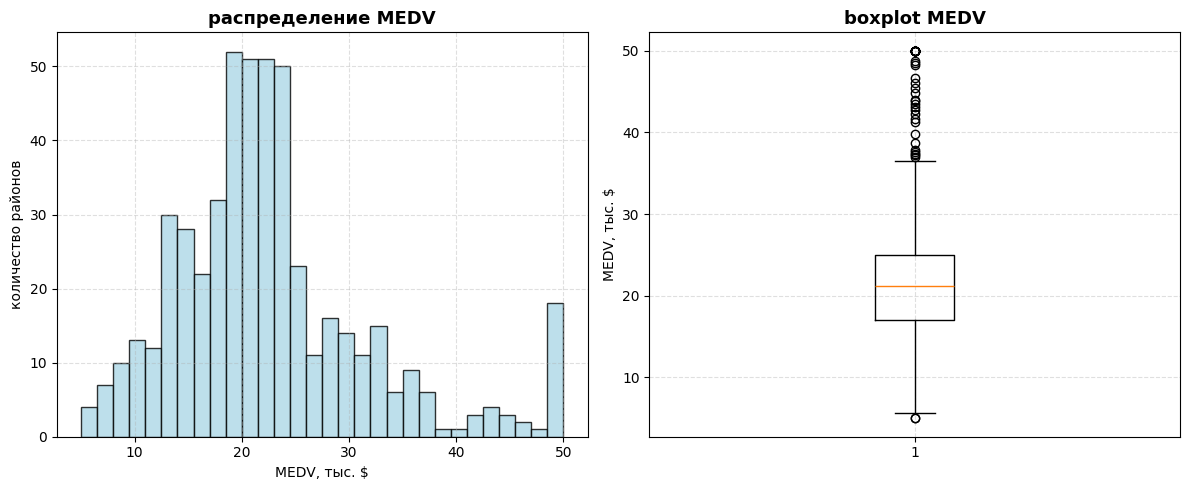

In [6]:
# постройте распределение MEDV (гистограмма + boxplot)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['MEDV'], bins=30, edgecolor='black', color='#add8e6', alpha=0.8)
axes[0].set_title('распределение MEDV', fontsize=13, fontweight='bold')
axes[0].set_xlabel('MEDV, тыс. $')
axes[0].set_ylabel('количество районов')
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].boxplot(df['MEDV'], vert=True)
axes[1].set_title('boxplot MEDV', fontsize=13, fontweight='bold')
axes[1].set_ylabel('MEDV, тыс. $')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


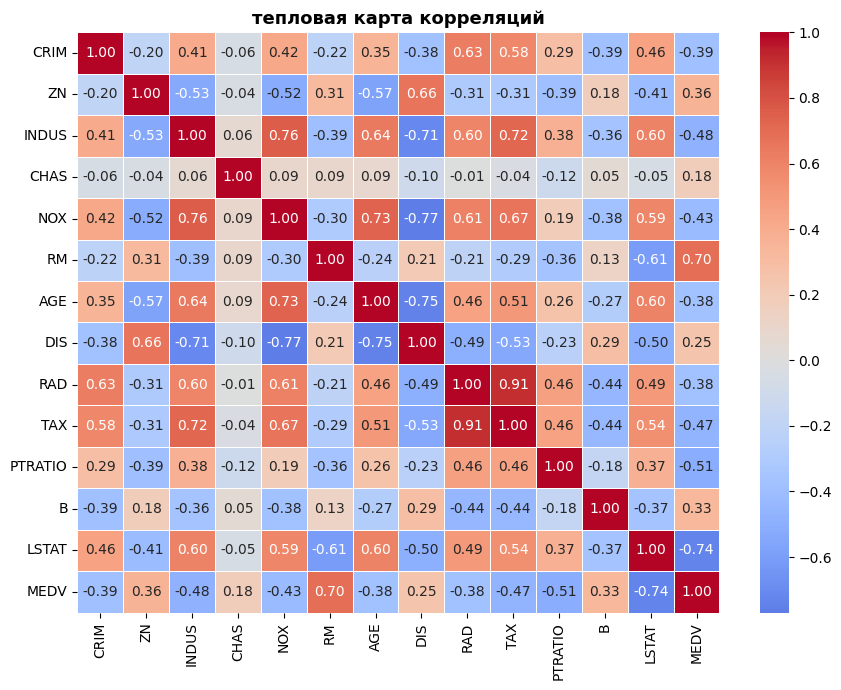

In [7]:
import seaborn as sns

# найдите признаки с наибольшей корреляцией с MEDV
corr_medv = df.corr()['MEDV'].sort_values(ascending=False)
print(corr_medv)  # сортировка по убыванию корреляции с ценой

# то же самое картинкой -- так нагляднее видно, что сильнее всего давит на цену
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('тепловая карта корреляций', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**выводы по заданию 1:**

- всего 506 строк, 13 признаков + MEDV, пропусков нет ни одного
- CHAS и RAD подгрузились как `category`, а не число
- MEDV скошено вправо: медиана 21.2, среднее 22.5 (среднее выше медианы -- хвост справа)
- максимум ровно 50.0, и на нём сразу 16 районов, следующее значение только 48.8. столько одинаковых цен на самом верху говорит о том, что всё дороже 50 при сборе данных просто записали как 50 (обрезали)
- сильнее всего с MEDV коррелируют RM (0.70, больше комнат -- дороже жильё) и LSTAT (-0.74, больше бедного населения рядом -- дешевле). PTRATIO тоже тянет цену вниз (-0.51)

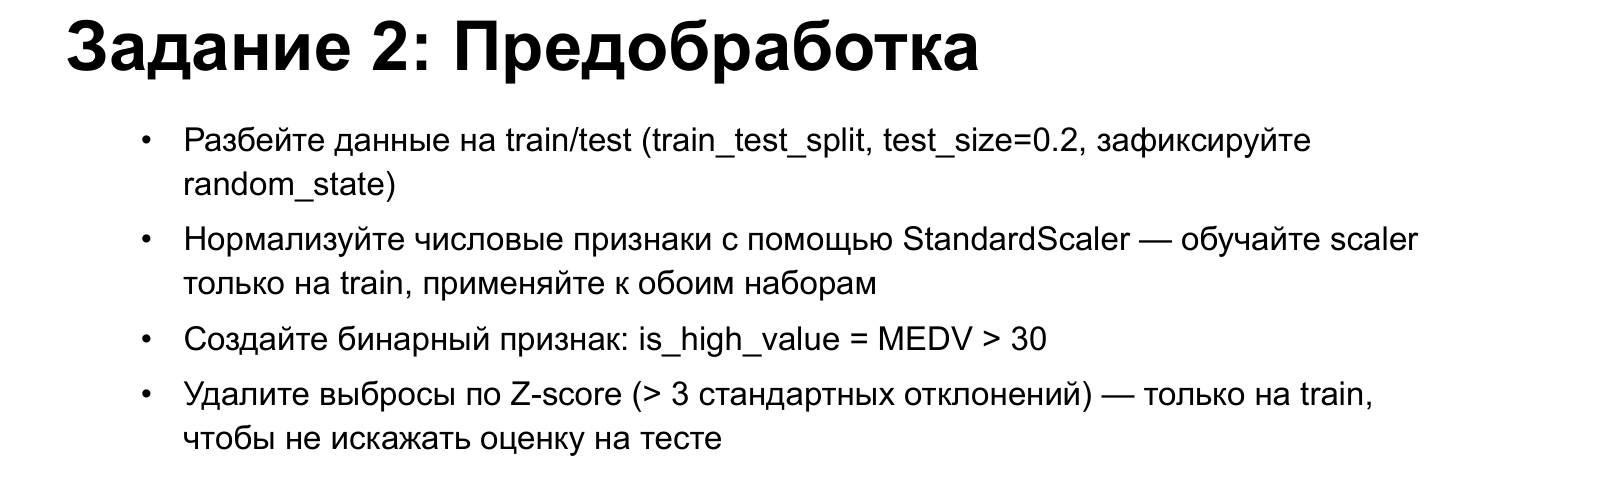

In [8]:
from sklearn.model_selection import train_test_split

# разбейте данные на train/test (train_test_split, test_size=0.2, зафиксируйте random_state)

# CHAS и RAD -- category, а не число
df['CHAS'] = df['CHAS'].astype(float)
df['RAD'] = df['RAD'].astype(float)

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print(train_df.shape, test_df.shape)

(404, 14) (102, 14)


In [9]:
from sklearn.preprocessing import StandardScaler

# нормализуйте числовые признаки с помощью standardscaler -- обучайте scaler только
# на train, применяйте к обоим наборам
features = [c for c in df.columns if c != 'MEDV']  # MEDV -- целевая, её не трогаем

scaler = StandardScaler()
train_scaled = train_df.copy()
test_scaled = test_df.copy()

train_scaled[features] = scaler.fit_transform(train_df[features])  # fit только на train
test_scaled[features] = scaler.transform(test_df[features])  # на test только transform, без fit

train_scaled[features].describe().round(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
count,404.00,404.00,404.00,404.00,404.00,404.00,404.00,404.00,404.00,404.00,404.00,404.00,404.00
mean,-0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.41,-0.50,-1.49,-0.28,-1.46,-3.46,-2.35,-1.26,-0.97,-1.31,-2.57,-3.89,-1.51
25%,-0.40,-0.50,-0.85,-0.28,-0.89,-0.60,-0.82,-0.81,-0.62,-0.75,-0.68,0.21,-0.80
50%,-0.38,-0.50,-0.35,-0.28,-0.16,-0.15,0.33,-0.30,-0.51,-0.45,0.17,0.38,-0.22
75%,-0.05,0.36,1.03,-0.28,0.63,0.45,0.90,0.75,0.31,1.58,0.85,0.43,0.55
max,9.63,3.82,2.43,3.60,2.68,3.48,1.12,3.91,1.71,1.85,1.65,0.44,3.59


In [10]:
# создайте бинарный признак: is_high_value = medv > 30
train_df['is_high_value'] = (train_df['MEDV'] > 30).astype(int)
test_df['is_high_value'] = (test_df['MEDV'] > 30).astype(int)

# масштабированные
train_scaled['is_high_value'] = train_df['is_high_value']
test_scaled['is_high_value'] = test_df['is_high_value']

train_df['is_high_value'].value_counts()

is_high_value
0    331
1     73
Name: count, dtype: int64

**что такое Z-score:**

Z-score (стандартизированное значение) показывает, на сколько стандартных отклонений конкретное значение отстоит от среднего:

$$Z = \dfrac{x - \mu}{\sigma}$$

где $\mu$ — среднее по признаку, $\sigma$ — стандартное отклонение. Если $Z = 0$, значение ровно на среднем, если $|Z| = 1$ — отклонилось на одно стандартное отклонение и т.д.

Для нормально распределённых данных за пределами $|Z| > 3$ лежит меньше 0.3% значений, поэтому такой порог обычно и берут как границу выброса — значение считается подозрительно далёким от типичного.

В нашем случае считать заново ничего не нужно: `StandardScaler` на предыдущем шаге как раз и перевёл все признаки в Z-score (вычел среднее и поделил на std, посчитанные на train), так что `train_scaled` уже хранит готовые Z-значения.

In [11]:
# удалите выбросы по z-score (> 3 стандартных отклонений) -- только на train,
# чтобы не искажать оценку на тесте
z = train_scaled[features].abs()  # после standardscaler значения и есть z-score
outlier_mask = (z > 3).any(axis=1)
print('выбросов:', outlier_mask.sum(), 'из', len(train_df))

train_df = train_df[~outlier_mask].reset_index(drop=True)
train_scaled = train_scaled[~outlier_mask].reset_index(drop=True)

train_df.shape

выбросов: 71 из 404


(333, 15)

**выводы по заданию 2:**

- сплит 404/102 (80/20), `random_state=42` -- воспроизводимо
- scaler обучен только на train, к train и test применён отдельно (`fit_transform` / `transform`)
- `is_high_value`: 73 дорогих района (MEDV > 30), 331 обычных -- в train
- по z-score вылетело 71 строка из 404 (17.6%) -- порог в 3 std считаем сразу по 13 признакам, а часть из них (например CRIM) сильно скошены, поэтому у них "выбросов" находится больше обычного

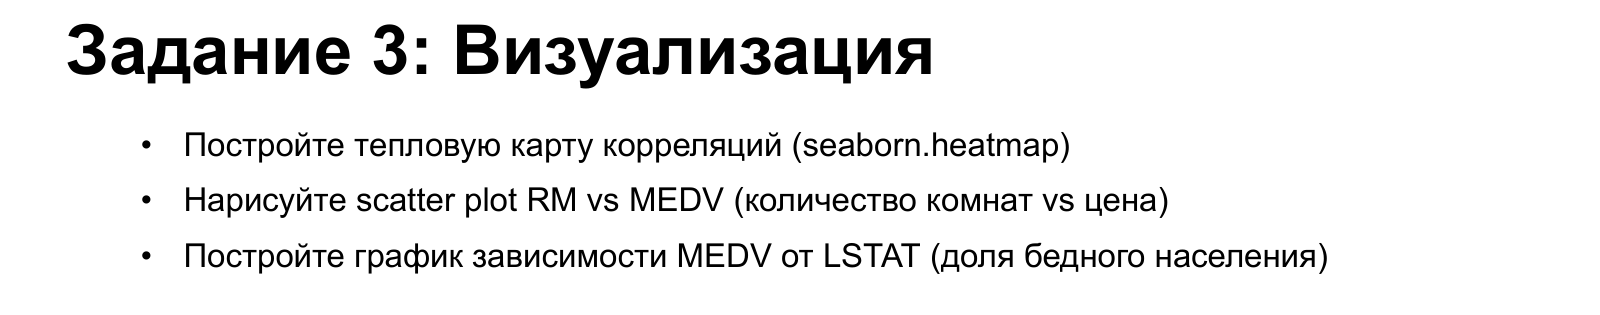

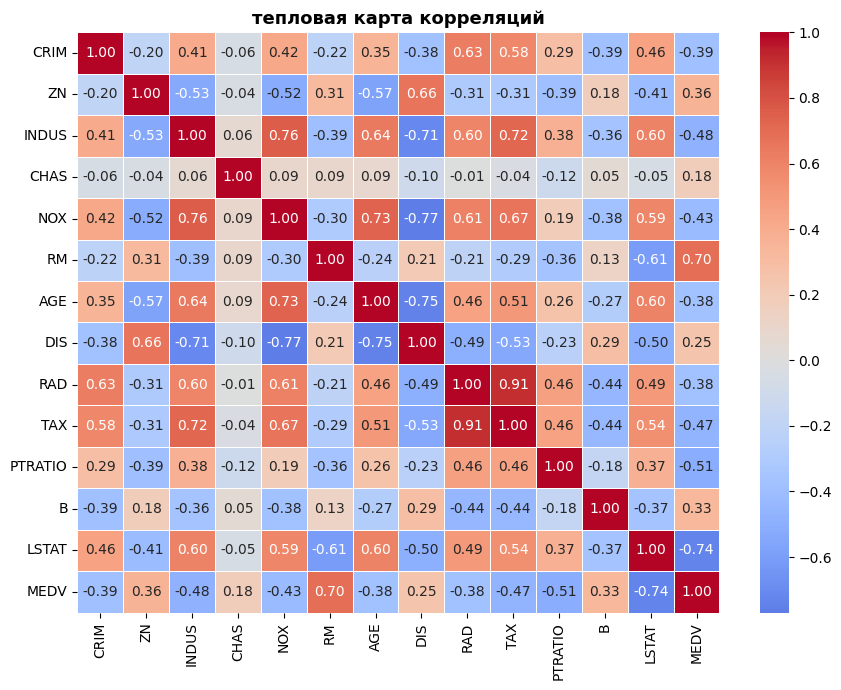

In [12]:
# постройте тепловую карту корреляций (seaborn.heatmap)
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('тепловая карта корреляций', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

видим то же самое, что и в задании 1: сильнее всего на MEDV влияют RM и LSTAT. ещё заметна сильная связь между RAD и TAX (0.91)

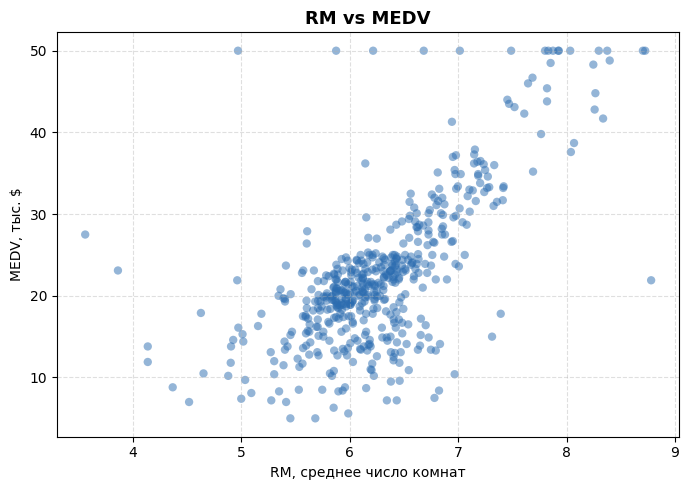

In [13]:
# нарисуйте scatter plot rm vs medv (количество комнат vs цена)
plt.figure(figsize=(7, 5))
plt.scatter(df['RM'], df['MEDV'], alpha=0.5, color='#2b6cb0', edgecolor='none')
plt.title('RM vs MEDV', fontsize=13, fontweight='bold')
plt.xlabel('RM, среднее число комнат')
plt.ylabel('MEDV, тыс. $')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

зависимость похожа на линейную и положительную -- больше комнат, дороже жильё, облако точек вытянуто по диагонали

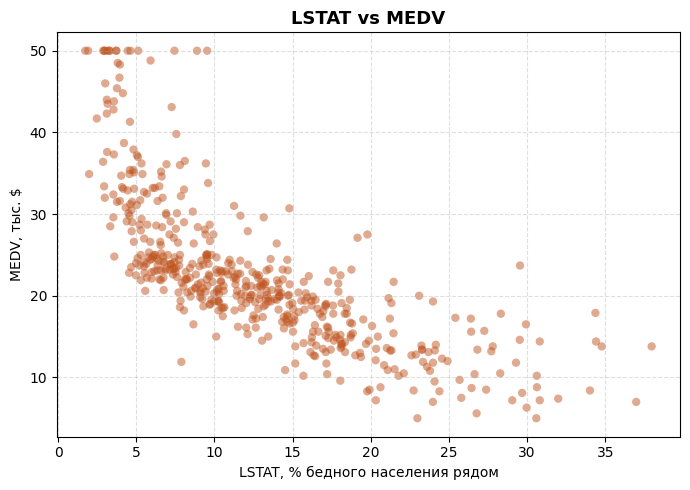

In [14]:
# постройте график зависимости medv от lstat (доля бедного населения)
plt.figure(figsize=(7, 5))
plt.scatter(df['LSTAT'], df['MEDV'], alpha=0.5, color='#c05621', edgecolor='none')
plt.title('LSTAT vs MEDV', fontsize=13, fontweight='bold')
plt.xlabel('LSTAT, % бедного населения рядом')
plt.ylabel('MEDV, тыс. $')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

зависимость отрицательная, но не прямая линия, а кривая -- на малых LSTAT цена падает резко, а на больших уже почти не меняется. значит, прямой линией эту зависимость до конца не описать

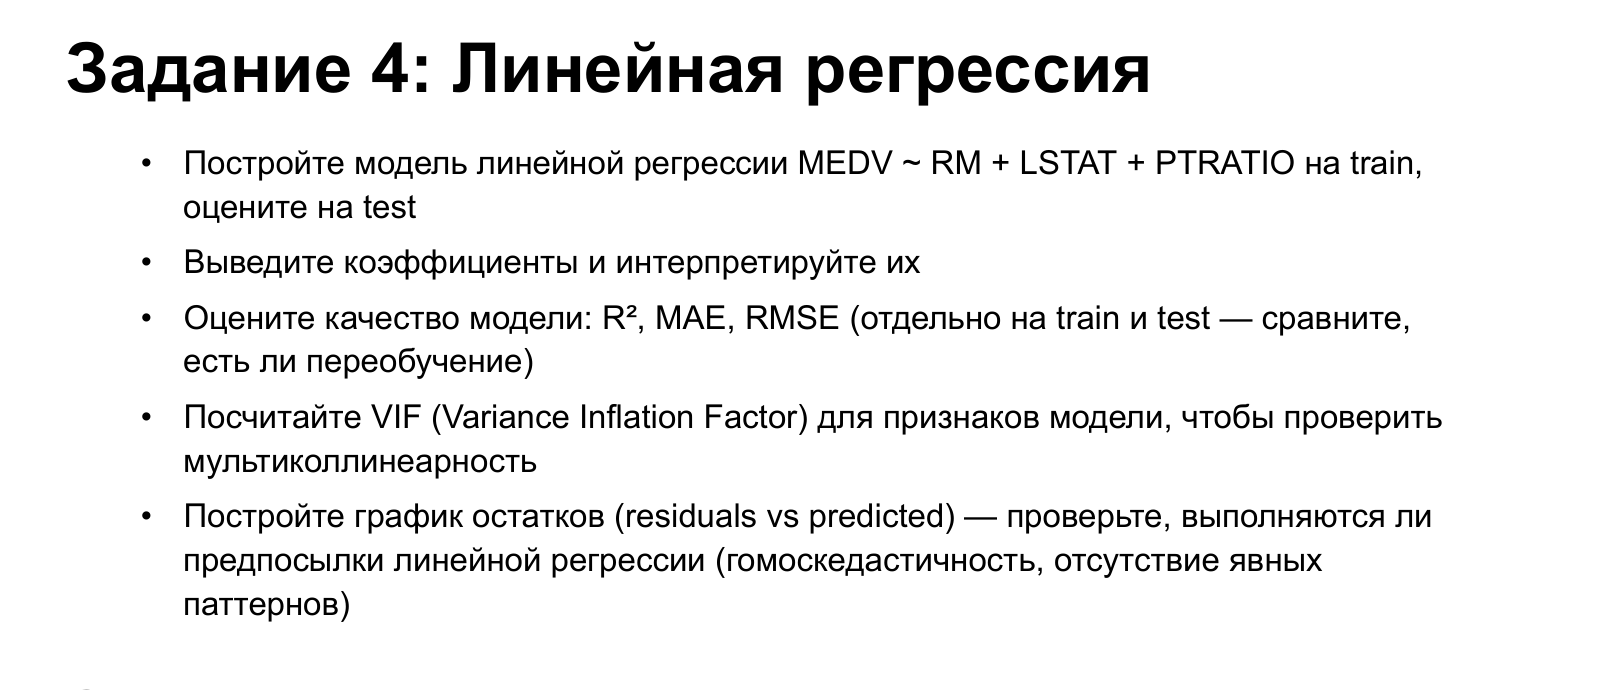

**что такое линейная регрессия:**

модель ищет линейную зависимость между признаками и целевой переменной:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$$

где:

- $\hat{y}$ -- прогноз модели (у нас цена MEDV)
- $x_1, \dots, x_n$ -- признаки (у нас RM, LSTAT, PTRATIO)
- $\beta_0$ -- intercept, значение прогноза, когда все признаки равны нулю
- $\beta_i$ -- коэффициент при признаке: на сколько меняется прогноз, если этот признак вырастет на 1, а остальные не меняются

коэффициенты подбираются так, чтобы суммарная ошибка (прогноз минус факт, в квадрате) была как можно меньше -- это метод наименьших квадратов (МНК)

In [15]:
from sklearn.linear_model import LinearRegression

# постройте модель линейной регрессии medv ~ rm + lstat + ptratio на train, оцените на test
X_cols = ['RM', 'LSTAT', 'PTRATIO']
X_train, y_train = train_df[X_cols], train_df['MEDV']
X_test, y_test = test_df[X_cols], test_df['MEDV']

model = LinearRegression()
model.fit(X_train, y_train)

pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

In [23]:
# выведите коэффициенты и интерпретируйте их
coef_table = pd.DataFrame({
    'признак': X_cols + ['b0'],
    'коэффициент': list(model.coef_) + [model.intercept_],
    'интерпретация': [
        'больше комнат -- дороже жильё',
        'больше доля бедного населения рядом -- дешевле жильё',
        'больше учеников на одного учителя -- дешевле жильё',
        'от нее считает',
    ],
})
coef_table

,признак,коэффициент,интерпретация
0,RM,5.784136,больше комнат -- дороже жильё
1,LSTAT,-0.487668,больше доля бедного населения рядом -- дешевле...
2,PTRATIO,-0.804518,больше учеников на одного учителя -- дешевле ж...
3,b0,6.930032,от нее считает


**что такое переобучение:**

- модель слишком подстроилась под train (запомнила его особенности), а на новых данных работает хуже
- признак: на train метрики заметно лучше, чем на test
- если метрики на train и test близки -- переобучения нет

In [24]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from IPython.display import display

# оцените качество модели: r2, mae, rmse (train и test -- сравните, есть ли переобучение)
metric_info = pd.DataFrame({
    'показатель': ['R²', 'MAE', 'RMSE'],
    'что означает': [
        'лучше чем просто средний результат выводить',
        'MAE = (1/n) * Σ|факт - прогноз|',
        'RMSE = √((1/n) * Σ(факт - прогноз)²)',
    ],
})

def metrics_values(y_true, y_pred):
    return [r2_score(y_true, y_pred), mean_absolute_error(y_true, y_pred), np.sqrt(mean_squared_error(y_true, y_pred))]

train_metrics = metric_info.copy()
train_metrics['значение'] = metrics_values(y_train, pred_train)

test_metrics = metric_info.copy()
test_metrics['значение'] = metrics_values(y_test, pred_test)

print('train:')
display(train_metrics.round(3))
print('test:')
display(test_metrics.round(3))

train:


,показатель,что означает,значение
0,R²,лучше чем просто средний результат выводить,0.722
1,MAE,MAE = (1/n) * Σ|факт - прогноз|,3.133
2,RMSE,RMSE = √((1/n) * Σ(факт - прогноз)²),4.366


test:


,показатель,что означает,значение
0,R²,лучше чем просто средний результат выводить,0.612
1,MAE,MAE = (1/n) * Σ|факт - прогноз|,3.316
2,RMSE,RMSE = √((1/n) * Σ(факт - прогноз)²),5.333


по определению выше сравниваем train и test:

- R²: 0.72 на train, 0.61 на test
- MAE: 3.13 на train, 3.32 на test -- почти одинаково
- RMSE: 4.37 на train, 5.33 на test -- на test заметно больше

на test хуже, особенно по R² и RMSE, значит небольшое переобучение есть. часть разницы из-за того, что выбросы по Z-score убирали только из train

**что такое VIF:**

VIF показывает, насколько признак $x_i$ похож на остальные признаки модели, выражается ли через них:

- если $x_i$ никак не связан с другими -- VIF = 1
- чем сильнее связан, тем VIF больше, и тем меньше можно доверять его коэффициенту в модели

$$VIF_i = \dfrac{1}{1 - R_i^2}$$

$R_i^2$ -- насколько хорошо можно предсказать сам признак $x_i$ по остальным признакам

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# посчитайте vif (variance inflation factor) для признаков модели, чтобы проверить мультиколлинеарность
X_vif = X_train.copy()
X_vif.insert(0, 'const', 1.0)  # statsmodels отдельно просит константу

vif_table = pd.DataFrame({
    'признак': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_table

,признак,VIF
0,const,1.000000
1,RM,1.689578
2,LSTAT,1.677959
3,PTRATIO,1.140971


- VIF у RM, LSTAT и PTRATIO маленький
- типо эти три признака почти не связаны друг с другом
- RAD и TAX, у них была сильная связь, но сюда они не попали

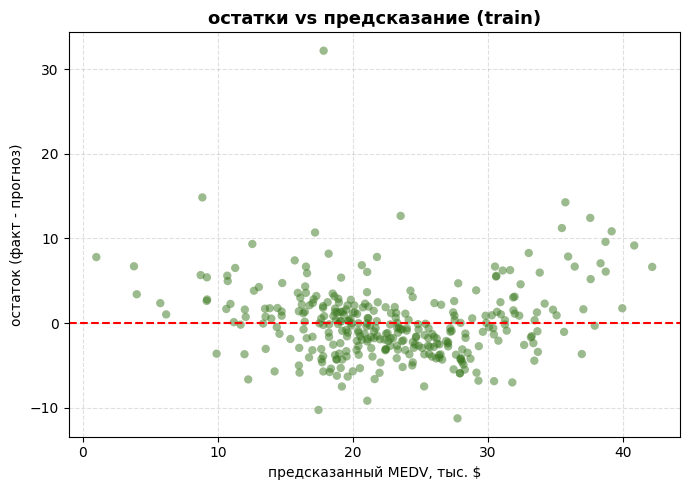

In [19]:
# постройте график остатков (residuals vs predicted) -- проверьте гомоскедастичность и паттерны
residuals = y_train - pred_train

plt.figure(figsize=(7, 5))
plt.scatter(pred_train, residuals, alpha=0.5, color='#38761d', edgecolor='none')
plt.axhline(0, color='red', linestyle='--')
plt.title('остатки vs предсказание (train)', fontsize=13, fontweight='bold')
plt.xlabel('предсказанный MEDV, тыс. $')
plt.ylabel('остаток (факт - прогноз)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**что видим на графике остатков:**

- линейность: точки идут дугой (буквой U), значит прямая линия описывает связь не до конца
- разброс: примерно одинаковый, толщина полосы почти не меняется (в середине чуть уже)
- выбросы: есть несколько точек далеко от остальных, сверху

**анализ остатков и мультиколлинеарности -- что они говорят о качестве и ограничениях модели:**

**остатки:**

- точки идут дугой: на самых дешёвых и самых дорогих районах модель занижает цену, а в середине завышает. причина в том, что цена зависит от признаков не по прямой (например, от LSTAT -- по кривой), а модель считает по прямой
- разброс примерно одинаковый: модель ошибается примерно на одну и ту же величину и на дешёвых, и на дорогих районах
- есть выбросы: несколько районов, где модель сильно промахнулась
- вывод о качестве: модель простая, ловит общий тренд, но не ловит изгибы, поэтому на краях ошибается всегда в одну сторону

**мультиколлинеарность** (сильная связь признаков между собой):

- VIF у RM, LSTAT и PTRATIO 1.1-1.7, порог 5-10, то есть эти три признака между собой почти не связаны
- вывод: коэффициентам модели можно верить, например "+1 комната = +5.78 тыс.$". здесь проблем с ней нет

**ограничения модели:**

- считает связь прямой, а у LSTAT она кривая -- отсюда дуга в остатках
- учитывает всего три признака, остальные (преступность, налог и т.д.) не использует: R² на test 0.61, то есть около 40% разброса цен модель не объясняет
- на новых данных работает хуже, чем на train (R² 0.61 против 0.72)

**выводы по корреляциям и модели:**

- сильнее всего с ценой связаны LSTAT (-0.74) и RM (0.70), PTRATIO тоже связан отрицательно (-0.51)
- в модель взяли RM, LSTAT и PTRATIO: больше комнат -- цена выше, больше бедного населения и больше учеников на учителя -- цена ниже
- R² на train 0.72, на test 0.61, RMSE на test 5.33 тыс.$ (средняя цена 22.5 тыс.$)

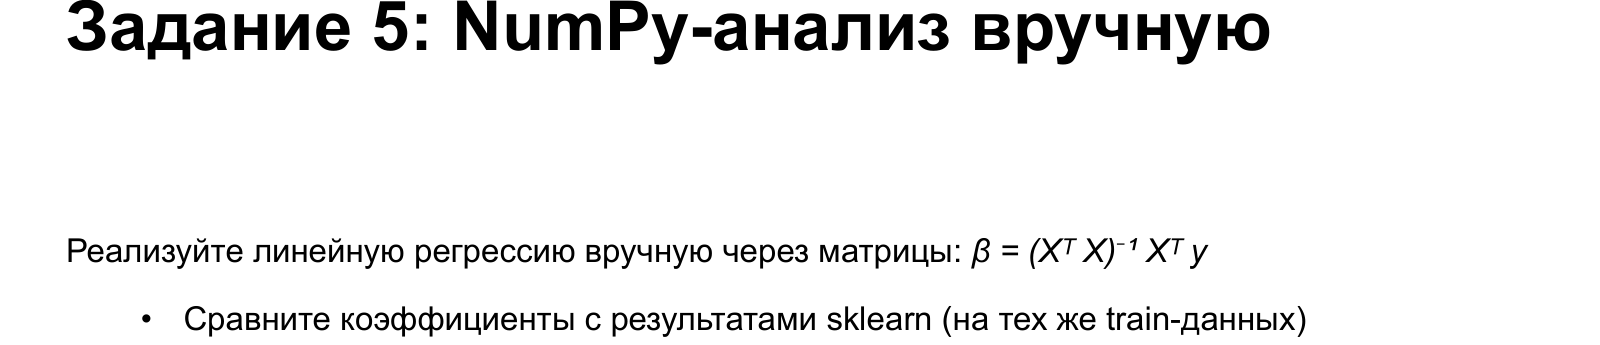

**как считаем вручную:**

- X -- матрица признаков (RM, LSTAT, PTRATIO) плюс столбец из единиц, чтобы заодно получить intercept
- y -- вектор из MEDV

формула

$$\beta = (X^TX)^{-1}X^Ty$$

сразу даёт все коэффициенты одним вычислением, без всяких итераций -- это точное решение метода наименьших квадратов, то же самое, что sklearn считает у себя внутри

In [20]:
# реализуйте линейную регрессию вручную через матрицы: β = (xᵀx)⁻¹xᵀy
X_manual = np.column_stack([np.ones(len(X_train)), X_train.values])  # столбец единиц -- под intercept
y_manual = y_train.values

beta = np.linalg.inv(X_manual.T @ X_manual) @ X_manual.T @ y_manual
beta

array([ 6.93003244,  5.7841364 , -0.48766832, -0.80451807])

In [21]:
# сравните коэффициенты с результатами sklearn (на тех же train-данных)
compare_table = pd.DataFrame({
    'признак': ['intercept'] + X_cols,
    'sklearn': [model.intercept_] + list(model.coef_),
    'вручную (numpy)': beta,
})
compare_table['разница'] = compare_table['sklearn'] - compare_table['вручную (numpy)']
compare_table

,признак,sklearn,вручную (numpy),разница
0,intercept,6.930032,6.930032,-9.929835e-13
1,RM,5.784136,5.784136,1.962874e-13
2,LSTAT,-0.487668,-0.487668,1.099121e-14
3,PTRATIO,-0.804518,-0.804518,-1.487699e-14


коэффициенты совпадают вплоть до 12-го знака после запятой -- разница только из-за округления при вычислениях с плавающей точкой. sklearn внутри считает то же самое, просто другим числовым методом

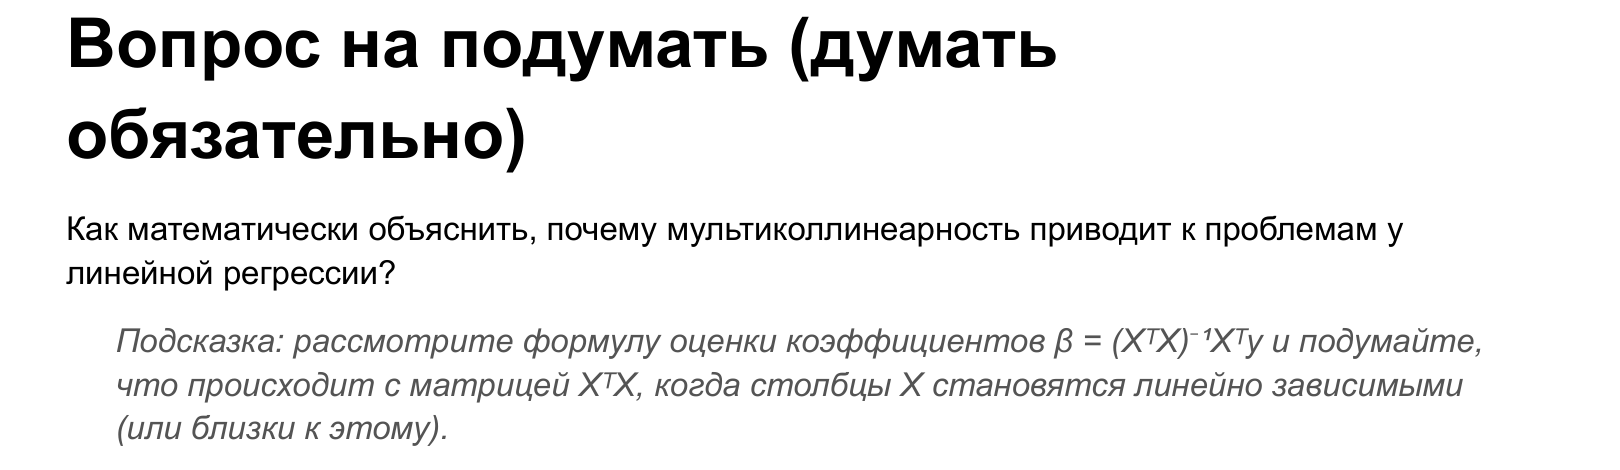

**что такое мультиколлинеарность:** когда признаки в модели сильно связаны между собой, то есть один признак почти можно выразить через другой.

смотрим на формулу

$$\beta = (X^TX)^{-1}X^Ty$$

чтобы посчитать $\beta$, нужно обратить матрицу $X^TX$. всё упирается в то, можно ли её обратить.

**признаки полностью зависимы**, например $x_2 = 2x_1$. тогда определитель $X^TX$ равен 0, обратной матрицы нет, и формула не работает. коэффициентов при этом бесконечно много: $\beta_1 x_1 + \beta_2 \cdot 2x_1 = (\beta_1 + 2\beta_2)x_1$, значит, подойдут любые $\beta_1$ и $\beta_2$ с одинаковой суммой $\beta_1 + 2\beta_2$. например, $\beta_1=4, \beta_2=0$ и $\beta_1=0, \beta_2=2$ дают один и тот же прогноз $4x_1$.

**признаки почти зависимы.** определитель не 0, но очень маленький, поэтому обратная матрица считается, но числа в ней получаются огромные. разброс коэффициентов считается через неё:

$$Var(\beta) = \sigma^2 (X^TX)^{-1}$$

где $\sigma^2$ -- разброс ошибок модели. значит, разброс коэффициентов тоже огромный: чуть поменяли данные -- коэффициенты сильно изменились, знак может даже перевернуться.

**итог:** прогнозы модели почти не страдают, а отдельным коэффициентам верить нельзя.

**возможные улучшения:**

- полиномиальные признаки -- например, добавить LSTAT², раз связь LSTAT с ценой кривая
- регуляризация (Ridge/Lasso) -- штраф за большие коэффициенты. помогает, когда признаки связаны между собой и когда на train заметно лучше, чем на test. Lasso ещё может обнулять ненужные признаки
- кросс-валидация -- вместо одного разбиения train/test считаем качество по нескольким разбиениям, оценка получается надёжнее

**рефлексия: какие признаки не стал бы использовать в реальной модели ценообразования:**

- B -- считается от доли чернокожего населения. оценивать жильё по расе жителей -- дискриминация, из-за этого признака датасет и убрали из sklearn
- LSTAT -- доля населения с низким социальным статусом. это тоже про жителей, а не про сам дом, и цена получается из-за того, кто рядом живёт